In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [18]:

data = {
"Hours_Studied": [
1,1.5,2,2.5,3,3.5,4,4.5,5,5.5,
6,6.5,7,7.5,8,8.5,9,9.5,10,10.5,
11,11.5,12,12.5,13,13.5,14,14.5,15,15.5,
16,16.5,17,17.5,18,18.5,19,19.5,20,
2.2,3.3,4.1,5.4,6.7,7.8,8.9,10.2,11.8,13.4,14.7
],

"Exam_Score": [
    38,40,42,44,46,48,50,52,54,56,
    58,60,62,64,66,68,70,72,74,76,
    78,80,82,84,86,87,88,89,90,91,
    92,93,94,95,96,97,98,99,100,
    43,47,51,55,61,65,69,75,81,85,89
]

}

df = pd.DataFrame(data)


In [19]:
df.sample(5)

,Hours_Studied,Exam_Score
1,1.5,40
32,17.0,94
36,19.0,98
49,14.7,89
48,13.4,85


In [20]:
class CustomLinearRegression:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X, y):
        x_mean = np.mean(X)
        y_mean = np.mean(y)

        X_minus_x_mean = X - x_mean
        y_minus_y_mean = y - y_mean

        num = np.sum(X_minus_x_mean * y_minus_y_mean)
        den = np.sum(X_minus_x_mean ** 2)

        self.m = num / den
        self.b = y_mean - self.m * x_mean

    def predict(self, X):
        return self.m * X + self.b

    def get_params(self):
        return self.m, self.b


        

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['Hours_Studied'], df['Exam_Score'], test_size=0.2, random_state=42)



In [22]:
custom_model = CustomLinearRegression()
custom_model.fit(X_train, y_train)

y_pred = custom_model.predict(X_test)




In [23]:
m, b = custom_model.get_params()

print(f"Slope: {m}")
print(f"Intercept: {b}")


Slope: 3.389442538024085
Intercept: 37.584247539792884


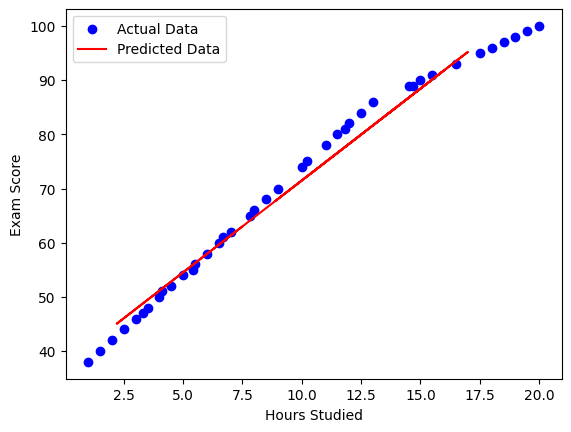

In [24]:
plt.scatter(X_train, y_train, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Predicted Data')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.show()


In [27]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate MSE
mse = mean_squared_error(y_test, y_pred)
# Calculate RMSE
rmse = np.sqrt(mse)
# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

# Calculate Adjusted R2 Score   
n = len(y_test)
p = 1  # Number of features (slope)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")
print(f"Adjusted R2 Score: {adj_r2}")

MSE: 4.725815785068116
RMSE: 2.1738941522227146
R2 Score: 0.9786548519192949
Adjusted R2 Score: 0.9759867084092068
